# 02_prepayment_and_credit_model · Prepayment & credit model: how each loan behaves month by month

**Purpose.** Turn loan characteristics plus a scenario (mortgage-rate path, house-price path) into monthly **prepayment**, **default** and **loss** rates per loan. Notebook 03 aggregates them into the pool cash-flow table for the waterfall.

**Process and the model behind each step.**
1. **Unit conversions** (`prepayment.calculate_smm`, `credit_model.cdr_to_mdr`): annual rates become monthly ones through 1 − CPR = (1 − SMM)¹². Survival compounds, so 6% CPR is 0.51%/month, not 6/12 = 0.50%.
2. **Refinancing incentive** (`prepayment.refi_incentive`): loan coupon − market mortgage rate, in percentage points.
3. **Prepayment, CPR** (`prepayment.calculate_cpr`):
   CPR = seasoning ramp × [turnover + refi_max × S-curve(incentive) × burnout]
   - *Turnover* (5.5%): moves and home sales, which happen even with no rate incentive.
   - *S-curve*: a logistic function. Little refinancing when out of the money, steep around +0.7 pp, flattening when deep in the money.
   - *Burnout*: loans that have stayed in the money without refinancing are less rate-sensitive, so the refi term decays with accumulated past incentive.
   - *Seasoning ramp*: new loans prepay less at first. The data says the ramp is only about 6 months, much faster than PSA's 30.
4. **Mark-to-market LTV** (`credit_model.mark_to_market_ltv`): tape HPI-adjusted LTV ÷ HPI path. Falling home prices raise LTV.
5. **Default rate** (`credit_model.calculate_credit_event_rate`): a proportional hazard. A base rate (0.40% a year of loans starting a default spell) is scaled up by higher MTM LTV (more steeply above 80, where borrowers lose equity), lower FICO, higher DTI, and investor occupancy. Loans 30 days delinquent on the tape get an extra hazard for 12 months.
6. **Severity** (`credit_model.calculate_loss_severity`): STACR is an **actual-loss** deal (PPM p. 172, 184), so there is no fixed severity. Loss = balance + 19 months of missed interest + 10% liquidation costs − distressed sale proceeds (property value × HPI × (1 − 48% discount)) − mortgage insurance (only for LTV > 80, so none in STACR DNA1).
7. **Modification loss** (`credit_model.modification_loss`): a modified loan's rate cut is a loss under STACR (PPM p. 84-85).

The scenario paths below are **placeholders** until Coco's `src/scenarios.py` is ready. The model parameters (the `PARAMS` dicts) are **fitted on Freddie Mac loan-level history** in notebook 05.

In [1]:
import sys, warnings
from pathlib import Path

# Find the repo root (the folder that contains src/) so imports work from anywhere
ROOT = Path.cwd()
while not (ROOT / "src").is_dir() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
warnings.filterwarnings("ignore", category=FutureWarning)  # pandas 2.2 + Python 3.14 noise

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
pd.set_option("display.float_format", "{:,.4f}".format)
print("repo root:", ROOT)

repo root: /Users/reza/Desktop/mfe-term_3/asset backed scurity market /stacr-crt-pricing


**Q&A · Setup**

**Q: Why does the first cell search upward for a folder containing `src/`?**
A: The model code lives in `src/` at the repo root. Jupyter may start in the repo root or in `notebooks/`, so the cell walks up the folder tree until it finds `src/` and adds that folder to `sys.path`. Then `from src import ...` works wherever the notebook is opened.

**Q: Why are FutureWarnings turned off? Doesn't that hide problems?**
A: pandas 2.2 running on Python 3.14 prints spurious "chained assignment" warnings from `clean.py`, which drown out the real output. Only *warnings* are hidden. Real errors still stop the cell, so nothing that would make a result wrong is suppressed.

In [2]:
def try_run(fn, *args, **kwargs):
    """Call a model function; if it's still a stub, say so instead of crashing."""
    try:
        return fn(*args, **kwargs)
    except NotImplementedError:
        print(f"-> {fn.__module__}.{fn.__name__} is not implemented yet")
        return None

**Q&A · `try_run`**

**Q: What does `try_run` do, and is it still needed?**
A: It calls a model function and, if the function raises `NotImplementedError`, prints "not implemented yet" instead of crashing. It dates from the scaffold stage, when the functions were empty stubs. Every function is implemented now, so `try_run` just returns the result. It's harmless and keeps the notebook runnable if a function is ever replaced by a stub again.

In [3]:
from src import prepayment as pp, credit_model as cm
pool = pd.read_parquet(ROOT / "data" / "processed" / "stacr_dna1.parquet")
print(f"{len(pool):,} loans, ${pool['Current Balance'].sum()/1e9:.2f}bn")

56,433 loans, $19.25bn


**Result · Loaded.** The full STACR pool (56,433 loans, $19.25bn, September tape) is in memory. The cells below use a **random sample of 2,000 loans** (`sample`) to keep plots fast. The sample's WA coupon is 6.76%, the same as the pool's.

**Q&A · Loading the pool**

**Q: Why use a 2,000-loan sample instead of all 56,433 loans?**
A: Every function here returns a matrix of loans × months (53 months), and some cells run it many times (Figure 1 runs 25 rate shocks). A random sample makes that fast while keeping the averages accurate: the sample's WA coupon is 6.76%, the same as the full pool. Notebook 03 uses the full pool, because the cash flows handed to the waterfall must add up to the real balance.

**Q: Why are the averages weighted by balance?**
A: Tranche cash flows and losses are in dollars, so a $1.9mm loan matters ten times more than a $190k loan. A simple average across loans would overweight small loans.

## Step 1 · Unit conversions

> Before coding: is 6% CPR really 0.5% per month? Why not?

In [4]:
cprs = np.array([0.0, 0.06, 0.10, 0.25, 0.60])
smm = try_run(pp.calculate_smm, cprs)
if smm is not None:
    display(pd.DataFrame({"CPR": cprs, "SMM": smm, "CPR/12": cprs / 12, "back to CPR": pp.smm_to_cpr(smm)}))

,CPR,SMM,CPR/12,back to CPR
0,0.0000,0.0000,0.0000,0.0000
1,0.0600,0.0051,0.0050,0.0600
2,0.1000,0.0087,0.0083,0.1000
3,0.2500,0.0237,0.0208,0.2500
4,0.6000,0.0735,0.0500,0.6000


**Result · Conversions.** 6% CPR → **0.51%** SMM (not 0.50%), 25% → **2.37%** (vs 2.08% naive), and 60% → **7.35%** (vs 5.00%). The last column returns the original CPRs exactly, so the two functions are consistent inverses.

**Q&A · Unit conversions**

**Q: Is 6% CPR really 0.5% a month? (the question in Step 1)**
A: No, it's **0.514%**. CPR is the share of the balance that prepays over a year. For a dollar to survive the year, it has to survive 12 months in a row: (1 − SMM)¹² = 1 − CPR = 0.94, so SMM = 1 − 0.94^(1/12) = 0.514%. Dividing by 12 ignores that each month's prepayments come out of a balance that's already smaller, so the monthly rate has to be a bit higher to remove 6% over the year.

**Q: Does the difference matter in practice?**
A: At 6% CPR it's tiny, but it grows with speed. At 60% CPR the naive 5.0% a month is far below the true 7.35%, which would understate monthly prepayments by about a third, overstate how long the notes stay outstanding (WAL), and misprice them.

**Q: What does the "back to CPR" column show?**
A: `smm_to_cpr(calculate_smm(x))` returns exactly the starting CPR, which proves the two functions are inverses. The test suite checks the same thing.

In [5]:
mdr = try_run(cm.cdr_to_mdr, np.array([0.002, 0.01, 0.05]))
print(mdr)

[0.00016682 0.00083718 0.00426532]


**Result · CDR → MDR.** 0.2% CDR = **0.017%** a month, 1% = 0.084%, and 5% = 0.43%. The fitted base rate of 0.40% a year is 0.033% a month. At prime-pool default rates MDR ≈ CDR/12; the compounding correction only matters at crisis-level rates.

**Q&A · CDR → MDR**

**Q: What does the fitted base rate of 0.40% a year mean?**
A: It's the annual probability that a *current* loan with mark-to-market LTV 80, FICO 750 and DTI 38 (post-2008 underwriting) misses a payment that turns into a 90+ day delinquency. Converted to monthly: 1 − (1 − 0.004)^(1/12) = 0.033%. The loan's own LTV, FICO, DTI and occupancy then scale this up or down.

**Q: Is 0.40% a year the rate at which loans become losses?**
A: No. In the Freddie data only **43%** of these default spells end in a liquidation. The rest cure, are modified or pay off. So the rate of loans actually liquidated is about 0.40% × 43% ≈ 0.17% a year at the base covariates.

**Q: Why convert at all, if MDR ≈ CDR/12 at these levels?**
A: The model runs month by month, so it needs monthly rates. The exact conversion costs nothing and stays correct under stress, where annual default rates of 5–10% make CDR/12 noticeably wrong.

## Step 3 · Prepayment: refi incentive and the S-curve

Placeholder flat rate path until Coco's `scenarios.py` is ready. Replace with her paths.

In [6]:
N_MONTHS = 53                                    # today -> Feb 2031 call
sample = pool.sample(2_000, random_state=0)      # small sample while developing
flat_rate = np.full(N_MONTHS, 6.25)              # placeholder 30y mortgage rate (%)

inc = try_run(pp.refi_incentive, sample, flat_rate)
if inc is not None:
    print("incentive month 1, WA:", np.average(inc[:, 0], weights=sample["Current Balance"]))

incentive month 1, WA: 0.5089670077068962


**Result · Incentive.** At a 6.25% market rate the sample's WA incentive is **+0.51 pp**, just below the fitted S-curve midpoint (+0.71 pp), on the steep part of the curve. Note that PMMS is now **7.28%** (Oct 2026), which would put the pool about **0.5 pp out of the money** (see notebook 05).

**Q&A · Refinancing incentive**

**Q: Why measure incentive against the PMMS rate?**
A: A borrower refinances into whatever rate lenders offer now. PMMS (Freddie's weekly 30-year survey) is the standard measure of that rate, and the prepayment model was calibrated against PMMS. Scenario rate paths fed into `calculate_cpr` should therefore be PMMS-type 30-year mortgage rates, not Treasury or SOFR rates.

**Q: Why is the WA incentive +0.51 pp, and what is it today?**
A: The sample's WA coupon is 6.76%, and this placeholder path assumes a 6.25% market rate: 6.76 − 6.25 = +0.51 pp. At today's PMMS of **7.28%** the incentive is about **−0.52 pp**, so the typical borrower would pay a *higher* rate by refinancing.

**Q: Why doesn't the model include refinancing costs?**
A: They're captured implicitly by the fitted S-curve midpoint of +0.71 pp. Borrowers need roughly that much rate saving before refinancing pays for closing costs and effort, so the curve is steepest there.

### Figure 1 · CPR vs. refinancing incentive

> Shape check: flat (turnover) when out of the money, steep near +50–150 bp, flattening (burnout) beyond.

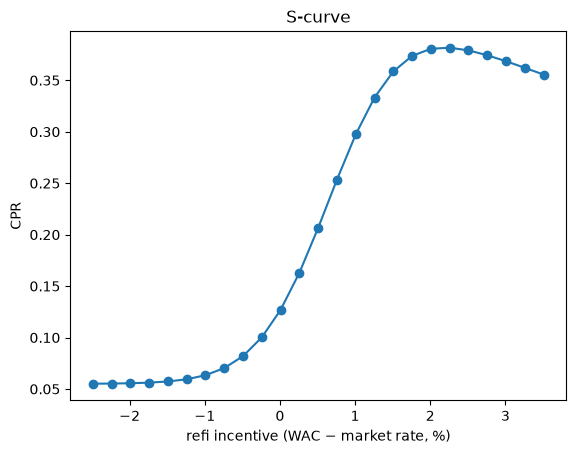

In [7]:
shifts = np.arange(-3.0, 3.01, 0.25)              # parallel rate shocks (%)
curve = []
for s in shifts:
    c = try_run(pp.cpr, sample, flat_rate + s)
    if c is None:
        break
    curve.append(np.average(c[:, 12], weights=sample["Current Balance"]))  # CPR in month 12
if curve:
    wac = np.average(sample["Gross Coupon"], weights=sample["Current Balance"])
    plt.plot(wac - (6.25 + shifts), curve, marker="o")
    plt.xlabel("refi incentive (WAC − market rate, %)"); plt.ylabel("CPR"); plt.title("S-curve")

**Result · Figure 1 (WA CPR in month 12 vs incentive, fitted parameters).**
- **Out of the money** (rates up 1–3 pp): CPR flattens at about **5.5%**, the fitted turnover floor.
- **At 6.25%** (+0.51 pp): about **21% CPR**, in line with the ~23% the pool has actually paid since cut-off.
- **Steep zone**: from 0 to +1 pp, CPR rises **13% → 30%**. A 50 bp rally adds about 8–9 points of CPR, which is the source of the notes' **negative convexity**.
- **Peak and roll-over**: CPR tops out at about **38%** around +2 pp and eases to **35.5%** at +3.5 pp because of **burnout**.

**Q&A · Figure 1, the S-curve**

**Q: Why is the curve shaped like an S?**
A: Out of the money, only *turnover* prepays (people moving or selling), about 5.5% a year, whatever rates do. Near break-even, a growing share of borrowers find refinancing worthwhile, so speeds climb steeply. Deep in the money, almost everyone who can refinance has done so. The rest are limited by credit, income or inertia, so the curve flattens.

**Q: Why does CPR *fall* at the deepest incentives (38% → 35.5%)?**
A: The figure shows CPR in **month 12**. With a deep incentive, the most responsive borrowers refinance in the first months. The burnout term (which accumulates past incentive) then lowers the speed of the borrowers left. The deeper the incentive, the more burnout has built up by month 12.

**Q: What does this mean for a STACR investor?**
A: STACR notes are floating-rate (SOFR + spread), so they don't gain or lose much price from rate moves the way fixed-rate MBS do. What prepayment changes is **how long** the investor keeps earning the spread and **how long** the notes are exposed to losses. Falling rates mean faster paydown, a shorter WAL and less spread income. Rising rates (today) mean slower paydown, longer exposure and more time for defaults to reach the tranches.

## Step 4 · Credit: MTM LTV, default rate, severity, modification losses

> At HPI LTV ≈ 70 and a 10% HPI drop, is there any loss before costs? So what drives severity here?

In [8]:
hpi_paths = {                                     # placeholders until Coco delivers
    "good":     np.linspace(1.00, 1.25, N_MONTHS + 1),
    "base":     np.linspace(1.00, 1.15, N_MONTHS + 1),
    "moderate": np.linspace(1.00, 0.90, N_MONTHS + 1),
    "severe":   np.linspace(1.00, 0.75, N_MONTHS + 1),
}
ltv = try_run(cm.mark_to_market_ltv, sample, hpi_paths["severe"])
if ltv is not None:
    print("WA MTM LTV at end, severe:", np.average(ltv[:, -1], weights=sample["Current Balance"]))

WA MTM LTV at end, severe: 94.08799290491194


**Result · MTM LTV.** By the end of the 53 months, WA LTV goes from 70.5 today to **56** (good, HPI +25%), **61** (base, HPI +15%), **78** (moderate, −10%) and **94** (severe, −25%). In the severe path the average borrower has only about 6% equity left, and many are underwater.

**Q&A · Mark-to-market LTV**

**Q: Why divide the tape LTV by the HPI path?**
A: LTV = loan balance / home value. The tape's HPI-adjusted LTV is measured at today's prices (HPI = 1.0). If prices later move to HPI_t, the home is worth HPI_t times as much, so LTV_t = LTV_today / HPI_t. A 25% decline turns LTV 70.5 into 94.

**Q: The function ignores amortization. Is that a problem?**
A: Over 53 months these loans amortize only about 5–6% of their balance, so ignoring it slightly *overstates* LTV. That's conservative (more defaults, higher severity) and simpler.

**Q: At HPI LTV ≈ 70 and a 10% price drop, is there any loss before costs? (the question in Step 4)**
A: No. The home would still be worth 1/0.70 × 0.90 = **1.29×** the loan balance at HPI-indexed value. Losses come from the *distressed* sale: the fitted 48% discount cuts proceeds to about 0.67× the balance, and 10% costs plus 19 months of missed interest come on top. That's why severity is about 54% in the moderate path, not zero.

### Figure 2 · Credit event rate by scenario

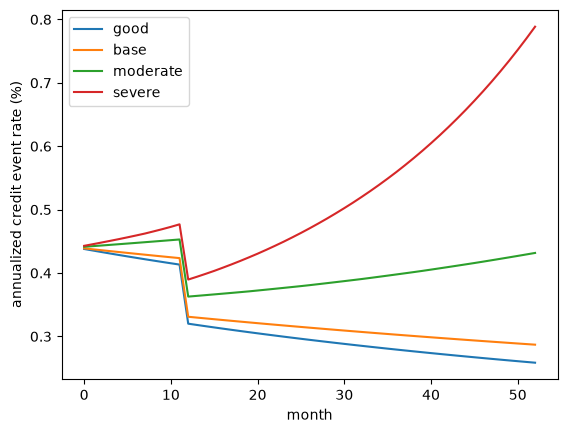

In [9]:
for name, hpi in hpi_paths.items():
    d = try_run(cm.calculate_credit_event_rate, sample, hpi)
    if d is None:
        break
    plt.plot(np.average(d, axis=0, weights=sample["Current Balance"]) * 12 * 100, label=name)
else:
    plt.xlabel("month"); plt.ylabel("annualized credit event rate (%)"); plt.legend()

**Result · Figure 2 (annualized default-spell rate by scenario, fitted).** All four start at about **0.44%** a year, vs 0.23% with the placeholders. Both fitted inputs are higher: the base rate (0.40% vs 0.20% a year) and the roll rate of loans 30 days late on the tape (24.5% reach 90+ within 12 months). After month 12 that extra hazard ends and every line steps down to about 0.32–0.39%. Then they diverge:
- **good**: falls to about **0.26%**, and **base** to about **0.29%** (rising prices build equity)
- **moderate**: edges up to about **0.43%**
- **severe**: climbs to about **0.79%** by 2031, about **1.5× base** on average (0.52% vs 0.34%)

The fitted LTV effect is milder than the placeholder's: +4% per LTV point above 80, vs 10% before.

**Q&A · Figure 2, default rate by scenario**

**Q: Why do falling home prices raise defaults?**
A: It's the "double trigger". A borrower who loses income but has equity can sell the home and repay the loan. One with little or no equity can't, so the same shock becomes a default. The model captures this through mark-to-market LTV, with a steeper effect above 80 (+4% per LTV point vs +2.1% below 80, fitted).

**Q: Why does every line step down after month 12?**
A: Loans 30 days late on the tape get an extra hazard of 2.28% a month for 12 months, matching the 24.5% of 30-day-late loans that reach 90+ within a year in the Freddie data. After month 12 that extra ends, and only the covariate-based hazard is left.

**Q: Why is severe only about 1.5× base on average, not much more?**
A: Prices fall linearly, so WA LTV only reaches 94 at the very end, and averages about 80 over the path. The pool's high FICO (759) and low starting LTV keep the hazard modest until equity is gone. A sharper or longer decline, or a path that adds unemployment, would raise it more.

In [10]:
for name, hpi in hpi_paths.items():
    sev = try_run(cm.calculate_loss_severity, sample, np.full(len(sample), hpi[-1]))
    if sev is None:
        break
    print(f"{name:9s} WA severity: {np.average(sev, weights=sample['Current Balance']):.1%}")

good      WA severity: 28.3%
base      WA severity: 35.5%
moderate  WA severity: 53.7%
severe    WA severity: 64.7%


**Result · Severity at the end of each path (fitted).** **28% good**, **35% base**, **54% moderate**, **65% severe**. Severity no longer drops to zero for low-LTV loans. In the Freddie data, liquidated homes sell about **48% below** their HPI-indexed value (deferred maintenance, vacancy, distressed buyers), and liquidation costs about 10% of UPB on top of 19 months of missed interest. Low-LTV liquidations in the data still lost about 23–42%. Severity still rises steeply as prices fall.

**Q&A · Severity**

**Q: Why is the fitted distressed-sale discount as large as 48%?**
A: Homes sold after foreclosure are usually vacant, poorly maintained and sold as-is, often to investors who demand a discount. Defaults also concentrate in neighborhoods that did worse than the national HPI, so the national index overstates these homes' value. The 48% is the discount that makes the model's average severity match the 17,430 actual Freddie liquidations (44.4% observed vs 45.5% model).

**Q: Why does severity matter so much for STACR?**
A: STACR is an **actual-loss** deal: tranches are written down by the realized loss on each liquidated loan, not a fixed percentage. Changing severity from about 4% to about 43% (base case) is what moved expected losses from 0.016% to 0.21% of the cut-off balance.

**Q: What would lower severity in practice?**
A: Mortgage insurance (only on loans above 80 LTV, so not for STACR DNA1, where every loan is at or below 80), short sales instead of REO sales, faster foreclosure timelines (fewer months of missed interest), and rising home prices.

In [11]:
# $ lost per month from a 2pp rate cut on $1mm of modified loans
try_run(cm.modification_loss, np.array([1_000_000.0]))

array([475.])

**Result · Modification loss.** With the fitted effective rate cut of 0.57 pp (an average 0.88 pp cut on the 37% of default spells that get modified, spread across all 57% that aren't liquidated), $1mm of modified loans loses **$475 a month**, about $5,700 a year. It's small next to liquidation losses, but under STACR's rules it reduces the junior classes' **interest** first.

**Q&A · Modification loss**

**Q: Why is a rate cut a *loss* in STACR?**
A: When Freddie modifies a loan, the reference pool earns less interest. Under the PPM (p. 84-85) that lost interest is allocated to the tranches as a modification loss: first cutting the junior classes' interest payments, then their principal. It counts even though the borrower keeps paying.

**Q: Why does the model use an effective cut of 0.57 pp when the data says 0.88 pp?**
A: Only 37% of default spells are modified, but the model applies the cut to all 57% that aren't liquidated. Scaling 0.88 pp × 37% / 57% = 0.57 pp makes total modification losses match the data.

**Q: Is it material?**
A: Not for the offered notes. $475 a month per $1mm modified is small next to liquidation losses of 40%+ of balance. It matters mostly to the B tranches' interest.

## Results and takeaways (fitted parameters, placeholder scenarios)

- **Conversions**: 6% CPR = 0.51% SMM and 60% CPR = 7.35% SMM. The gap from CPR/12 grows with speed, which is why you must not divide by 12.
- **Incentive**: at a 6.25% market rate the pool's WA incentive is **+0.51 pp**, on the steep part of the fitted S-curve. **But PMMS is now 7.28%**, which puts the pool out of the money.
- **Figure 1 (S-curve)**: CPR is flat at the ~5.5% turnover floor when out of the money, rises steeply between 0 and +1.5 pp, and peaks near 38%. The base case gives about **21% CPR**, consistent with the pool's paydown since cut-off.
- **MTM LTV**: a 25% home-price decline (severe) pushes WA LTV from 70 to **94**.
- **Figure 2 (default spells by scenario)**: about 0.44% a year at first (30-day-late loans rolling), then 0.26–0.29% (good / base), 0.43% (moderate) and 0.79% (severe) by 2031.
- **Severity**: **28% / 35% / 54% / 65%** (good / base / moderate / severe). The fitted distressed-sale discount (48%) and 10% costs mean even equity-rich loans lose money when liquidated. This is the biggest change from the placeholders, where severity was 0% in the base case.
- **Modification loss**: about $475 a month per $1mm modified.

**Caveats**: the model's severity is steeper in LTV than the data (notebook 05, section 6), and refinancing still doesn't fall when borrowers are underwater.